---
## 7. Análise de Logística & SLA

> **Objetivo:** Entender a eficiência operacional da Olist — onde estão os gargalos, quais regiões têm pior desempenho e qual é o tamanho real do problema de atrasos.

In [2]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import pandas as pd
df_base = pd.read_csv("../data/processed/base_analitica_final.csv")

# Estilo global dos gráficos
plt.rcParams.update({
    'figure.facecolor': 'white',
    'axes.facecolor':   'white',
    'axes.grid':        True,
    'grid.alpha':       0.3,
    'font.family':      'sans-serif',
})
print('✅ Matplotlib configurado.')

✅ Matplotlib configurado.


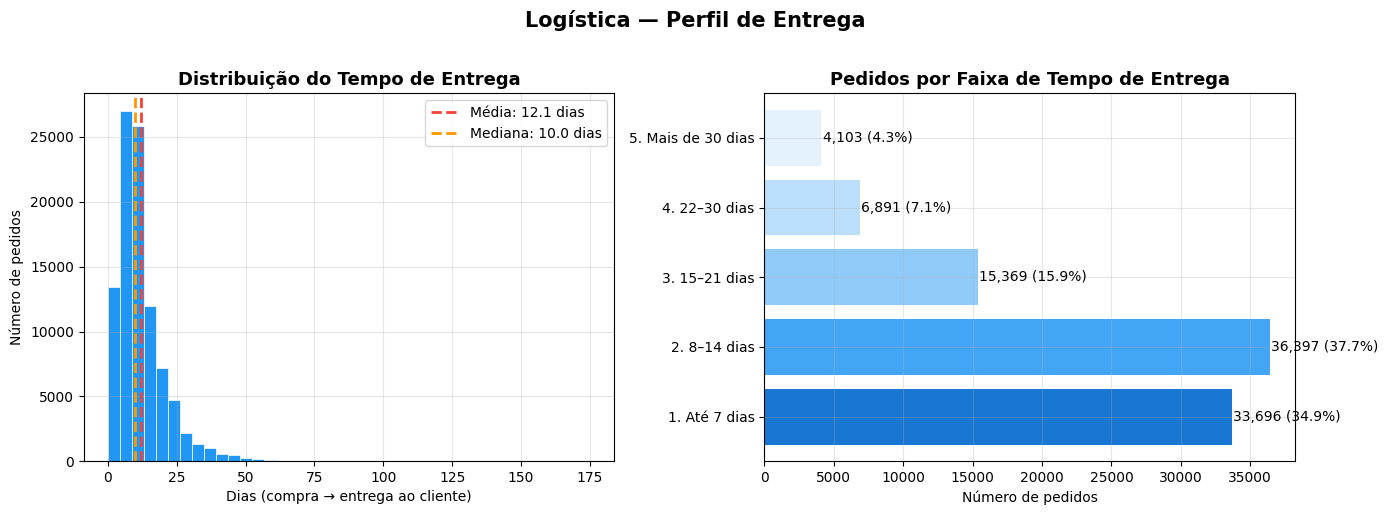


📊 Insight: 12.9% dos pedidos levam mais de 20 dias para ser entregues.


In [3]:
# ============================================================
# GRÁFICO 1 — DISTRIBUIÇÃO DO TEMPO DE ENTREGA
# ============================================================
# Por quê: mostra onde a maioria dos pedidos está concentrada
# e evidencia a cauda longa (pedidos com entrega muito demorada).
# Insight esperado: maioria entrega entre 5-25 dias,
# mas existe uma cauda relevante acima de 30 dias.
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histograma de tempo de entrega
axes[0].hist(
    df_base['tempo_entrega_dias'].dropna(),
    bins=40, color='#2196F3', edgecolor='white', linewidth=0.5
)
axes[0].axvline(df_base['tempo_entrega_dias'].mean(),   color='#F44336', lw=2, ls='--', label=f'Média: {df_base["tempo_entrega_dias"].mean():.1f} dias')
axes[0].axvline(df_base['tempo_entrega_dias'].median(), color='#FF9800', lw=2, ls='--', label=f'Mediana: {df_base["tempo_entrega_dias"].median():.1f} dias')
axes[0].set_title('Distribuição do Tempo de Entrega', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Dias (compra → entrega ao cliente)')
axes[0].set_ylabel('Número de pedidos')
axes[0].legend()

# Distribuição por faixa de entrega
faixas = df_base['faixa_entrega'].value_counts().sort_index()
colors = ['#1976D2','#42A5F5','#90CAF9','#BBDEFB','#E3F2FD']
bars = axes[1].barh(faixas.index, faixas.values, color=colors)
axes[1].set_title('Pedidos por Faixa de Tempo de Entrega', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Número de pedidos')
for bar, val in zip(bars, faixas.values):
    pct = val / faixas.sum() * 100
    axes[1].text(bar.get_width() + 100, bar.get_y() + bar.get_height()/2,
                 f'{val:,} ({pct:.1f}%)', va='center', fontsize=10)

plt.suptitle('Logística — Perfil de Entrega', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print(f'\n📊 Insight: {(df_base["tempo_entrega_dias"] > 20).mean()*100:.1f}% dos pedidos levam mais de 20 dias para ser entregues.')

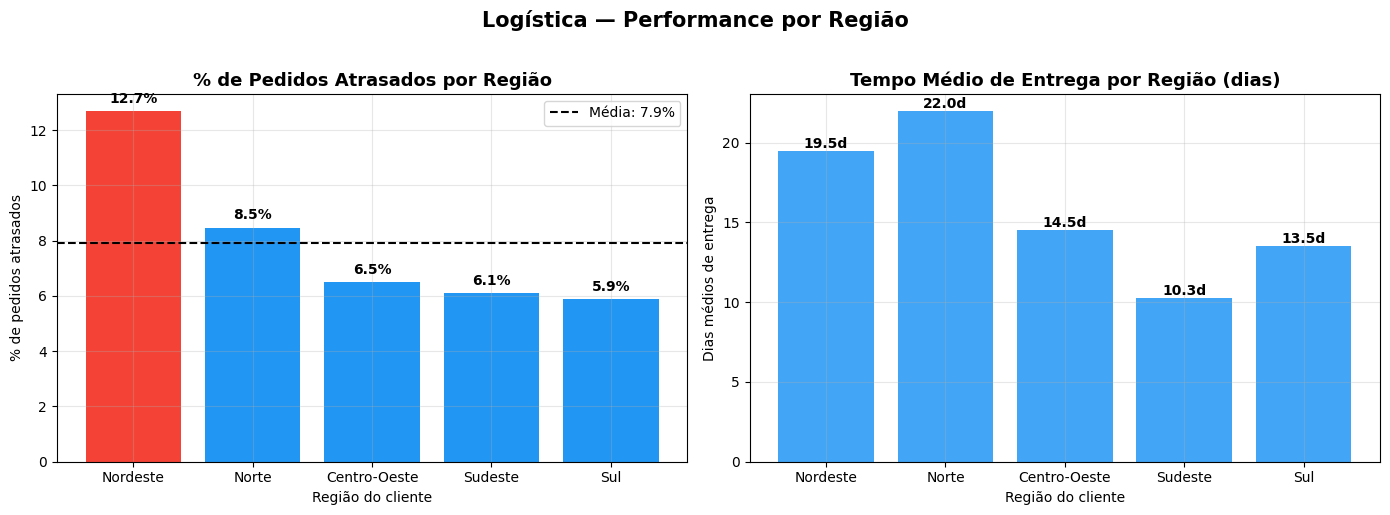


📊 Ranking de regiões com pior SLA:
regiao_cliente  % atrasado  tempo médio (dias)  pedidos
      Nordeste   12.676991           19.459513     9040
         Norte    8.472687           21.955964     1794
  Centro-Oeste    6.508981           14.534057     5623
       Sudeste    6.108358           10.274612    66188
           Sul    5.886612           13.532764    13811


In [4]:
# ============================================================
# GRÁFICO 2 — % DE PEDIDOS ATRASADOS POR REGIÃO
# ============================================================
# Por quê: identifica quais regiões têm maior problema de SLA.
# Regiões Norte e Nordeste tendem a ter maior % de atraso
# por distância e infraestrutura logística menos desenvolvida.
# ============================================================

# Calcula % de atraso e tempo médio de entrega por região
regiao_sla = df_base.groupby('regiao_cliente').agg(
    pct_atraso      = ('atrasado',          'mean'),
    tempo_medio     = ('tempo_entrega_dias', 'mean'),
    total_pedidos   = ('order_id',           'count')
).reset_index().sort_values('pct_atraso', ascending=False)

regiao_sla['pct_atraso_pct'] = regiao_sla['pct_atraso'] * 100

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# % de atraso por região
colors_bar = ['#F44336' if x > 10 else '#2196F3' for x in regiao_sla['pct_atraso_pct']]
bars = axes[0].bar(regiao_sla['regiao_cliente'], regiao_sla['pct_atraso_pct'], color=colors_bar)
axes[0].axhline(regiao_sla['pct_atraso_pct'].mean(), color='black', ls='--', lw=1.5, label=f'Média: {regiao_sla["pct_atraso_pct"].mean():.1f}%')
axes[0].set_title('% de Pedidos Atrasados por Região', fontsize=13, fontweight='bold')
axes[0].set_ylabel('% de pedidos atrasados')
axes[0].set_xlabel('Região do cliente')
axes[0].legend()
for bar, val in zip(bars, regiao_sla['pct_atraso_pct']):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                 f'{val:.1f}%', ha='center', fontsize=10, fontweight='bold')

# Tempo médio de entrega por região
bars2 = axes[1].bar(regiao_sla['regiao_cliente'], regiao_sla['tempo_medio'], color='#42A5F5')
axes[1].set_title('Tempo Médio de Entrega por Região (dias)', fontsize=13, fontweight='bold')
axes[1].set_ylabel('Dias médios de entrega')
axes[1].set_xlabel('Região do cliente')
for bar, val in zip(bars2, regiao_sla['tempo_medio']):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.2,
                 f'{val:.1f}d', ha='center', fontsize=10, fontweight='bold')

plt.suptitle('Logística — Performance por Região', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print('\n📊 Ranking de regiões com pior SLA:')
print(regiao_sla[['regiao_cliente','pct_atraso_pct','tempo_medio','total_pedidos']]
      .rename(columns={'pct_atraso_pct':'% atrasado','tempo_medio':'tempo médio (dias)','total_pedidos':'pedidos'})
      .to_string(index=False))

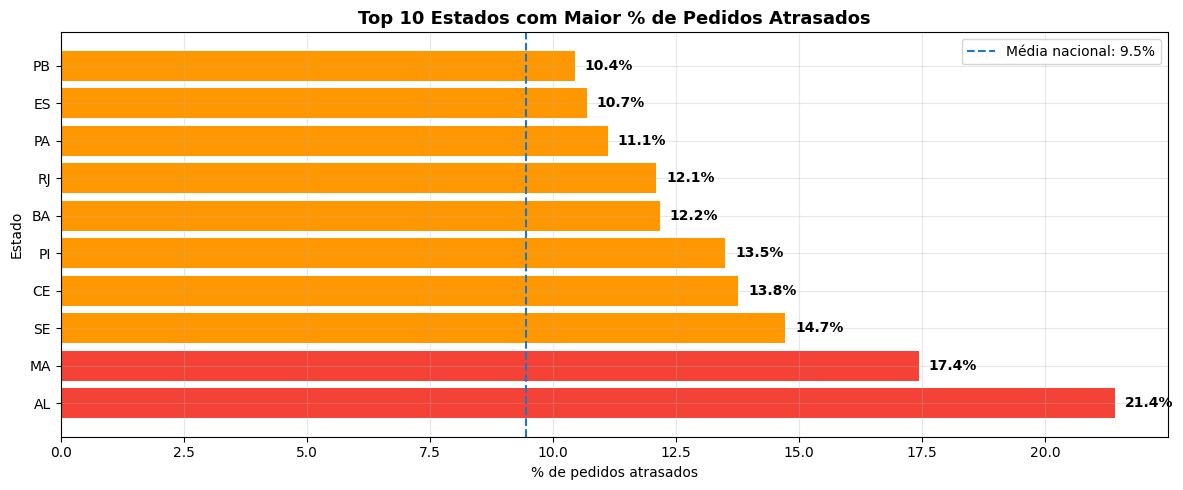


📊 Insight: Os 10 estados com pior SLA representam um risco elevado de insatisfação do cliente.


In [5]:
# ============================================================
# GRÁFICO 3 — TOP 10 ESTADOS COM MAIOR % DE ATRASO
# ============================================================
# Por quê: granularidade de estado permite direcionar
# ações operacionais específicas (renegociar transportadora,
# abrir centro de distribuição regional, etc.)
# Cores: vermelho > 15%, laranja > 10%, amarelo demais
# ============================================================

# Filtra estados com volume relevante (> 100 pedidos)
estado_sla = df_base.groupby('customer_state').agg(
    pct_atraso    = ('atrasado',          'mean'),
    tempo_medio   = ('tempo_entrega_dias', 'mean'),
    total_pedidos = ('order_id',           'count')
).reset_index()

estado_sla = estado_sla[estado_sla['total_pedidos'] >= 100].copy()
estado_sla['pct_atraso_pct'] = estado_sla['pct_atraso'] * 100
top10_estados = estado_sla.sort_values('pct_atraso_pct', ascending=False).head(10)

fig, ax = plt.subplots(figsize=(12, 5))

bars = ax.barh(
    top10_estados['customer_state'],
    top10_estados['pct_atraso_pct'],
    color=['#F44336' if x > 15 else '#FF9800' if x > 10 else '#FFC107'
           for x in top10_estados['pct_atraso_pct']]
)
ax.axvline(estado_sla['pct_atraso_pct'].mean(), color='#1976D2', ls='--', lw=1.5,
           label=f'Média nacional: {estado_sla["pct_atraso_pct"].mean():.1f}%')
ax.set_title('Top 10 Estados com Maior % de Pedidos Atrasados', fontsize=13, fontweight='bold')
ax.set_xlabel('% de pedidos atrasados')
ax.set_ylabel('Estado')
ax.legend()
for bar, val in zip(bars, top10_estados['pct_atraso_pct']):
    ax.text(bar.get_width() + 0.2, bar.get_y() + bar.get_height()/2,
            f'{val:.1f}%', va='center', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

print(f'\n📊 Insight: Os 10 estados com pior SLA representam um risco elevado de insatisfação do cliente.')

ANÁLISE DE PONTUALIDADE — VISÃO GERAL
  Total de pedidos analisados:   96,456
  ✅ Entregues no prazo:          89,936  (93.2%)
  ❌ Atrasados:                    6,520  (6.8%)

PONTUALIDADE POR REGIÃO
Região             Total   No prazo   % prazo   Atrasados   % atraso
-----------------------------------------------------------------
Nordeste           9,040      7,894     87.3%       1,146      12.7%
Norte              1,794      1,642     91.5%         152       8.5%
Centro-Oeste       5,623      5,257     93.5%         366       6.5%
Sudeste           66,188     62,145     93.9%       4,043       6.1%
Sul               13,811     12,998     94.1%         813       5.9%


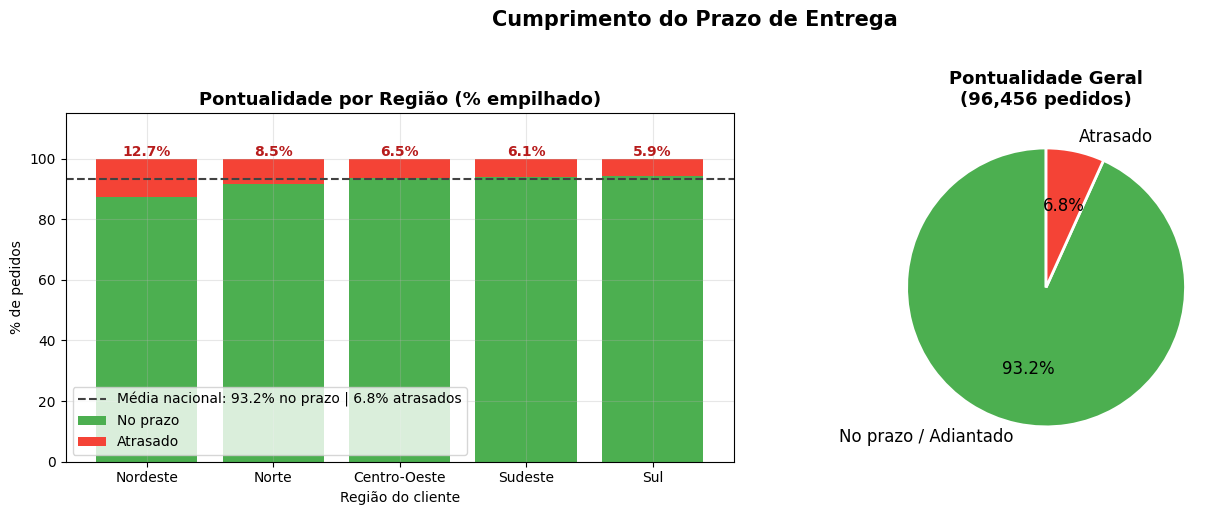

In [6]:
# ============================================================
# ANÁLISE: PEDIDOS NO PRAZO vs ATRASADOS
# ============================================================
# Por quê: quantifica exatamente o tamanho do problema de SLA.
# Mostra o split geral e depois abre por região para identificar
# onde a operação está fora de controle.
# ============================================================

# --- VISÃO GERAL ---
total        = len(df_base)
no_prazo     = (df_base['atrasado'] == 0).sum()
atrasado_tot = (df_base['atrasado'] == 1).sum()

print('=' * 55)
print('ANÁLISE DE PONTUALIDADE — VISÃO GERAL')
print('=' * 55)
print(f'  Total de pedidos analisados: {total:>8,}')
print(f'  ✅ Entregues no prazo:        {no_prazo:>8,}  ({no_prazo/total*100:.1f}%)')
print(f'  ❌ Atrasados:                 {atrasado_tot:>8,}  ({atrasado_tot/total*100:.1f}%)')

# --- VISÃO POR REGIÃO ---
regiao_prazo = df_base.groupby('regiao_cliente').agg(
    total         = ('order_id',  'count'),
    no_prazo      = ('atrasado',  lambda x: (x == 0).sum()),
    atrasados     = ('atrasado',  'sum'),
).reset_index()
regiao_prazo['pct_no_prazo']  = regiao_prazo['no_prazo']  / regiao_prazo['total'] * 100
regiao_prazo['pct_atrasados'] = regiao_prazo['atrasados'] / regiao_prazo['total'] * 100
pct_nacional_no_prazo = no_prazo / total * 100
pct_nacional_atrasado = atrasado_tot / total * 100
regiao_prazo = regiao_prazo.sort_values('pct_atrasados', ascending=False)

print('\n' + '=' * 55)
print('PONTUALIDADE POR REGIÃO')
print('=' * 55)
print(f'{"Região":<15} {"Total":>8} {"No prazo":>10} {"% prazo":>9} {"Atrasados":>11} {"% atraso":>10}')
print('-' * 65)
for _, r in regiao_prazo.iterrows():
    print(f'{r["regiao_cliente"]:<15} {r["total"]:>8,} {r["no_prazo"]:>10,} '
          f'{r["pct_no_prazo"]:>8.1f}% {r["atrasados"]:>11,} {r["pct_atrasados"]:>9.1f}%')

# --- GRÁFICO: NO PRAZO vs ATRASADO ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Barras empilhadas por região
regioes_ord = regiao_prazo['regiao_cliente'].tolist()
bars_prazo  = axes[0].bar(regioes_ord, regiao_prazo['pct_no_prazo'],  color='#4CAF50', label='No prazo')
bars_atraso = axes[0].bar(regioes_ord, regiao_prazo['pct_atrasados'], bottom=regiao_prazo['pct_no_prazo'],
                          color='#F44336', label='Atrasado')
axes[0].axhline(pct_nacional_no_prazo, color='#424242', ls='--', lw=1.5,
                label=f'Média nacional: {pct_nacional_no_prazo:.1f}% no prazo | {pct_nacional_atrasado:.1f}% atrasados')
axes[0].set_ylim(0, 115)
axes[0].set_title('Pontualidade por Região (% empilhado)', fontsize=13, fontweight='bold')
axes[0].set_ylabel('% de pedidos')
axes[0].set_xlabel('Região do cliente')
axes[0].legend()
for bar, val in zip(bars_atraso, regiao_prazo['pct_atrasados']):
    axes[0].text(bar.get_x() + bar.get_width()/2,
                 bar.get_y() + bar.get_height() + 1,
                 f'{val:.1f}%', ha='center', fontsize=10, fontweight='bold', color='#B71C1C')

# Pizza geral: no prazo vs atrasado
axes[1].pie(
    [no_prazo, atrasado_tot],
    labels=['No prazo / Adiantado', 'Atrasado'],
    autopct='%1.1f%%',
    colors=['#4CAF50', '#F44336'],
    startangle=90,
    wedgeprops={'edgecolor': 'white', 'linewidth': 2},
    textprops={'fontsize': 12}
)
axes[1].set_title(f'Pontualidade Geral\n({total:,} pedidos)', fontsize=13, fontweight='bold')

plt.suptitle('Cumprimento do Prazo de Entrega', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()